─── Cell 1: To-Do ─────────────────────────────────────────────
- Better temporal photobleach correction
- Possible correction for stimulation rate?
- Flagging? i.e. 1Hz cannot have APD90 of >1000ms, etc
- Alternans flagging (duration alternans)
- DAD and EAD flagging
- Fix occasional drifts
- Fix low amplitude peak detection, occasional
- Maybe start_idx (depolarization start) needs better detection settings?

─── Cell 1.5: Changelist ──────────────────────────────────────
- Added "Mean_Values" sheet with mean  
- Added standard deviation for each ROI measurement

In [1]:
# ─── Cell 2: Imports ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from itertools import groupby
from operator import itemgetter
import os
import io
import re 

In [ ]:
# ─── Cell 3: Load Excel Workbook & Inspect Sheets ──────────────────────────
np.random.seed(42)  # for reproducibility

# Path to the REAL workbook (template only, not shared in repo)
TEMPLATE_EXCEL = r"C://Users//. . .//Git//Private//Sup_Rep_BeRST_pilot_excel.xlsx"

# Path for SYNTHETIC workbook
SYNTHETIC_EXCEL = "Sup_Rep_BeRST_pilot_excel_SYNTHETIC.xlsx"

# How many time points to generate if needed
N_POINTS = 600
TIME_END = 3.0  # seconds


def make_synthetic_trace(n_points):
    """Single synthetic APD-like trace."""
    t = np.linspace(0, TIME_END, n_points)
    noise = np.random.normal(0, 0.02, n_points)
    signal = 1.2 * np.exp(-((t - 1.2) / 0.05) ** 2) + noise
    return t, signal


def build_synthetic_sheet(xls, sheet_name):
    """
    Read a sheet from the template workbook and build a synthetic
    version with the same columns & layout:
      - Row 0: sample name (string in A1)
      - Row 1+: No., Time, ROI columns (#...) with synthetic values
    """
    # Row 0: sample name row (used only for structure)
    raw = xls.parse(sheet_name, header=None, nrows=1)
    sample_name = str(raw.iloc[0, 0])

    # Row 1+: data with real headers
    df_real = xls.parse(sheet_name, header=1)
    df_real.columns = df_real.columns.astype(str).str.strip()

    # Identify columns
    cols = list(df_real.columns)
    no_col = next((c for c in cols if c.lower().startswith("no")), None)
    time_col = next((c for c in cols if "time" in c.lower()), None)
    roi_cols = [c for c in cols if "#" in c]

    # Decide how many points to generate
    n_points = len(df_real) if len(df_real) > 0 else N_POINTS

    # Build synthetic data
    data = {}
    if no_col is not None:
        data[no_col] = np.arange(1, n_points + 1)
    if time_col is not None:
        t, _ = make_synthetic_trace(n_points)
        data[time_col] = t

    for col in roi_cols:
        _, sig = make_synthetic_trace(n_points)
        data[col] = sig

    df_syn = pd.DataFrame(data)

    # Reorder columns to match original
    df_syn = df_syn[[c for c in cols if c in df_syn.columns]]

    # Compose sheet: top row with sample name, then synthetic data
    top = pd.DataFrame([[sample_name] + [None] * (len(df_syn.columns) - 1)],
                       columns=df_syn.columns)
    sheet_df = pd.concat([top, df_syn], ignore_index=True)
    return sheet_df


# Build synthetic workbook
xls = pd.ExcelFile(TEMPLATE_EXCEL)
with pd.ExcelWriter(SYNTHETIC_EXCEL) as writer:
    for sheet in xls.sheet_names:
        # Skip totally empty / helper sheets if needed
        df_real = xls.parse(sheet, header=1)
        if df_real.dropna(how="all").empty:
            continue

        sheet_df = build_synthetic_sheet(xls, sheet)
        sheet_df.to_excel(writer, sheet_name=sheet, index=False)

print(f"✅ Synthetic demo workbook created: {SYNTHETIC_EXCEL}")

APPLY_FILTERS        = True    # toggle filters
GREY_OUT_UNFILTERED  = True    # grey removed events on plots
band_factor     = 1.5
upstroke_min    = 0.06

C:\Users\Anhnh\AppData\Local\Temp\ipykernel_3848\2631852286.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sheet_df = pd.concat([top, df_syn], ignore_index=True)
C:\Users\Anhnh\AppData\Local\Temp\ipykernel_3848\2631852286.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sheet_df = pd.concat([top, df_syn], ignore_index=True)
C:\Users\Anhnh\AppData\Local\Temp\ipykernel_3848\2631852286.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated

✅ Synthetic demo workbook created: Sup_Rep_BeRST_pilot_excel_SYNTHETIC.xlsx


In [3]:
# ─── Cell 4: Core APD Utility Functions ────────────────────────────────────
def analyze_roi_signal(time, signal, sample_name, roi_label,
                       apply_filters=True,
                       grey_out_unfiltered=True):
    # --- Prep ---\
    signal = pd.to_numeric(signal, errors='coerce').dropna().values
    time   = time[: len(signal)]

    Fmin       = np.min(signal)
    normalized = (signal - Fmin) / Fmin
    smoothed   = gaussian_filter1d(normalized, sigma=1)

    slope_initial = np.gradient(smoothed, time)

    # Photobleaching correction
    flat_thresh = np.percentile(np.abs(slope_initial), 20)
    flat_idxs   = np.where(np.abs(slope_initial) < flat_thresh)[0]
    if flat_idxs.size >= 2:
        bleach_curve = np.interp(time, time[flat_idxs], smoothed[flat_idxs])
        bleach_curve[bleach_curve == 0] = 1
        smoothed = smoothed / bleach_curve

    # Thresholds
    s_max, s_med = np.max(smoothed), np.median(smoothed)
    dr            = s_max - s_med
    rising_thresh = 0.05 * dr
    depol_thresh  = 0.02 * dr

    slope = np.gradient(smoothed, time)

    # Rising-edge groups
    edges  = np.where(slope > rising_thresh)[0]
    groups = []
    for k, g in groupby(enumerate(edges), lambda x: x[0] - x[1]):
        grp = [i for _, i in g]
        if len(grp) >= 5:
            groups.append(grp)

    # Candidate peaks
    peeks = []
    for grp in groups:
        start = grp[0]
        end   = min(grp[-1] + 20, len(smoothed))
        peeks.append(np.argmax(smoothed[start:end]) + start)

    # De-dupe
    filt_peeks = []
    for p in peeks:
        if not filt_peeks or p - filt_peeks[-1] > 40:
            filt_peeks.append(p)

    # Metrics
    rows = []
    for pk in filt_peeks:
        window = range(max(0, pk - 100), pk)
        cand   = [i for i in window if slope[i] < depol_thresh]
        if not cand:
            continue
        start_idx = cand[-1]

        pre       = smoothed[max(0, start_idx - 50): start_idx]
        baseline  = np.min(pre)
        peak_val  = smoothed[pk]
        amp       = peak_val - baseline

        # APD90
        lvl90 = baseline + 0.1 * amp
        repol90_idx = next((i for i in range(pk + 1, len(smoothed)) if smoothed[i] <= lvl90), None)
        if repol90_idx is None:
            continue
        repol90_time  = time[repol90_idx]
        repol90_level = smoothed[repol90_idx]
        apd90         = repol90_time - time[start_idx]

        # APD50
        lvl50 = baseline + 0.5 * amp
        repol50_idx = next((i for i in range(pk + 1, len(smoothed)) if smoothed[i] <= lvl50), None)
        if repol50_idx is None:
            continue
        apd50 = time[repol50_idx] - time[start_idx]

        ratio50_90 = apd50 / apd90 if apd90 > 0 else np.nan
        upstroke   = time[pk] - time[start_idx]

        rows.append({
            'Depolarization_Start_Time_s': time[start_idx],
            'Peak_Time_s'                : time[pk],
            'Amplitude'                  : amp,
            'APD50_s'                    : apd50,
            'APD90_s'                    : apd90,
            'APD50_90_Ratio'             : ratio50_90,
            'Upstroke_Time_s'            : upstroke,
            'Repolarization_Time_s'      : repol90_time,
            'Repolarization_Level'       : repol90_level
        })

    # DataFrame
    df_res_raw = pd.DataFrame(rows).reset_index().rename(columns={'index': '_orig'})
    df_res     = df_res_raw.copy()

    # --- Filters ---
    if apply_filters and not df_res.empty:
        # Upstroke filter
        df_res = df_res[df_res['Upstroke_Time_s'] > upstroke_min]

        # Symmetric APD90 trim
        median_apd90 = df_res['APD90_s'].median()
        lower = median_apd90 / band_factor
        upper = median_apd90 * band_factor
        df_res = df_res[(df_res['APD90_s'] >= lower) & (df_res['APD90_s'] <= upper)]

        df_res = df_res.reset_index(drop=True)

    # Figure out which events were removed (only for plotting, not for summary printing)
    removed = (df_res_raw[~df_res_raw['_orig'].isin(df_res['_orig'])]
               if apply_filters and grey_out_unfiltered else
               pd.DataFrame(columns=df_res_raw.columns))

    expected = [
        'Depolarization_Start_Time_s', 'Peak_Time_s', 'Amplitude',
        'APD50_s', 'APD90_s', 'APD50_90_Ratio', 'Upstroke_Time_s',
        'Repolarization_Time_s', 'Repolarization_Level'
    ]
    df_res = df_res.reindex(columns=['_orig'] + expected)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(time, smoothed, label='Signal')

    # Grey-out removed (if desired)
    if grey_out_unfiltered and not removed.empty:
        for i, t in enumerate(removed['Peak_Time_s']):
            ax.axvline(t, color='grey', linestyle='--', alpha=0.3,
                       label='Removed Peak' if i == 0 else None)
        for i, t in enumerate(removed['Depolarization_Start_Time_s']):
            ax.axvline(t, color='grey', linestyle=':', alpha=0.3,
                       label='Removed Depol Start' if i == 0 else None)
        for i, row in enumerate(removed.itertuples()):
            ax.hlines(y=row.Repolarization_Level,
                      xmin=row.Depolarization_Start_Time_s,
                      xmax=row.Repolarization_Time_s,
                      color='grey', linestyle='-', linewidth=2, alpha=0.3,
                      label='Removed APD90' if i == 0 else None)

    # Kept events
    for i, t in enumerate(df_res['Peak_Time_s']):
        ax.axvline(t, color='green', linestyle='--', alpha=0.8,
                   label='Peak' if i == 0 else None)
    for i, t in enumerate(df_res['Depolarization_Start_Time_s']):
        ax.axvline(t, color='black', linestyle='--', alpha=0.5,
                   label='Depol Start' if i == 0 else None)
    for i, row in enumerate(df_res.itertuples()):
        ax.hlines(y=row.Repolarization_Level,
                  xmin=row.Depolarization_Start_Time_s,
                  xmax=row.Repolarization_Time_s,
                  color='red', linestyle='-', linewidth=2, alpha=0.8,
                  label='APD90' if i == 0 else None)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("ΔF/Fmin")
    ax.set_title(f"{sample_name} | {roi_label} (bleach-corrected)")
    ax.grid(True)
    fig.tight_layout()

    return sample_name, roi_label, df_res, fig

Displaying plot for: SUPH222P_PostISO002 | #1 (Mono - Tx Red)


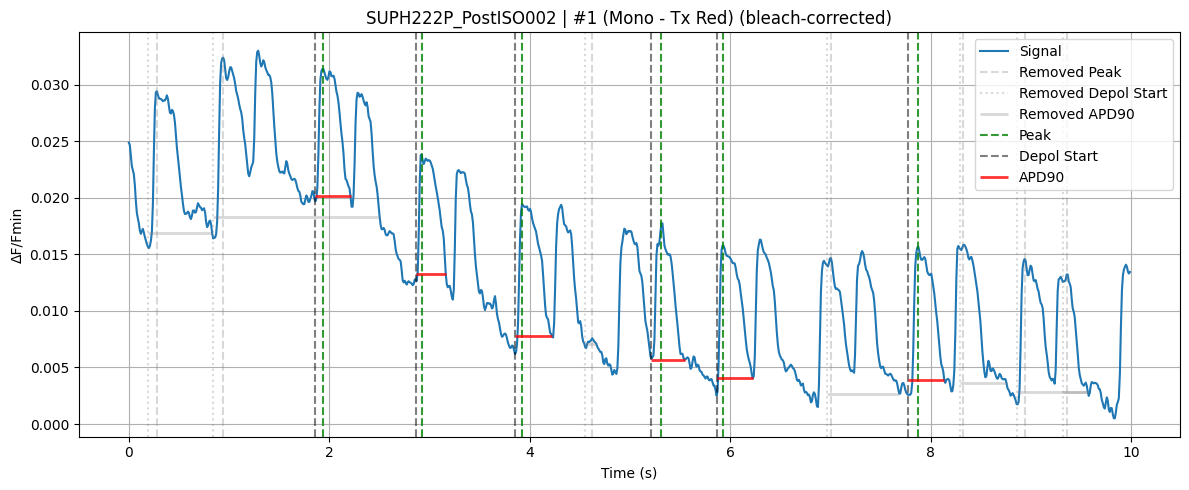

Displaying plot for: SUPH222P_PostISO002 | #2 (Mono - Tx Red)


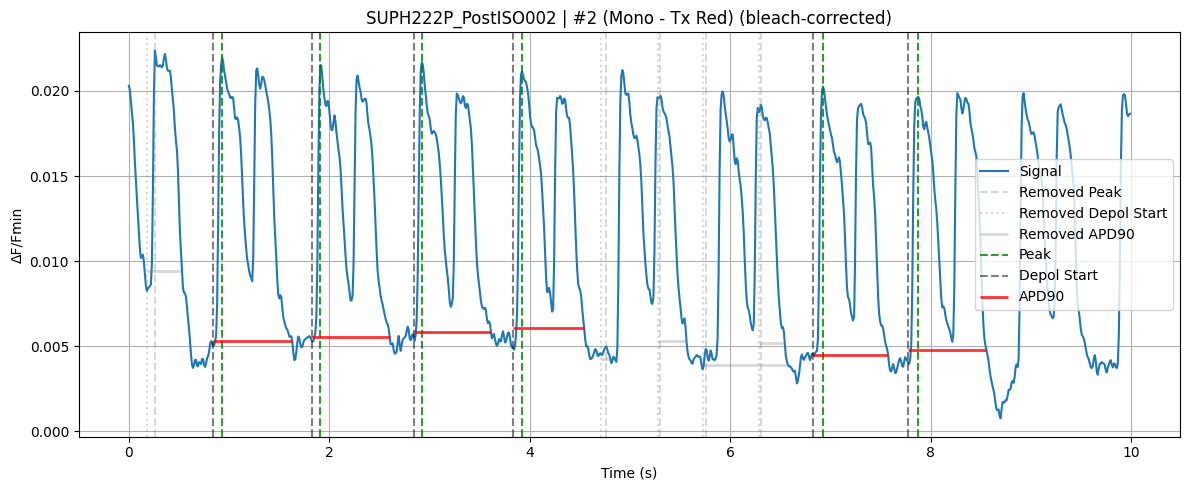

Displaying plot for: SUPH222P_PostISO002 | #3 (Mono - Tx Red)


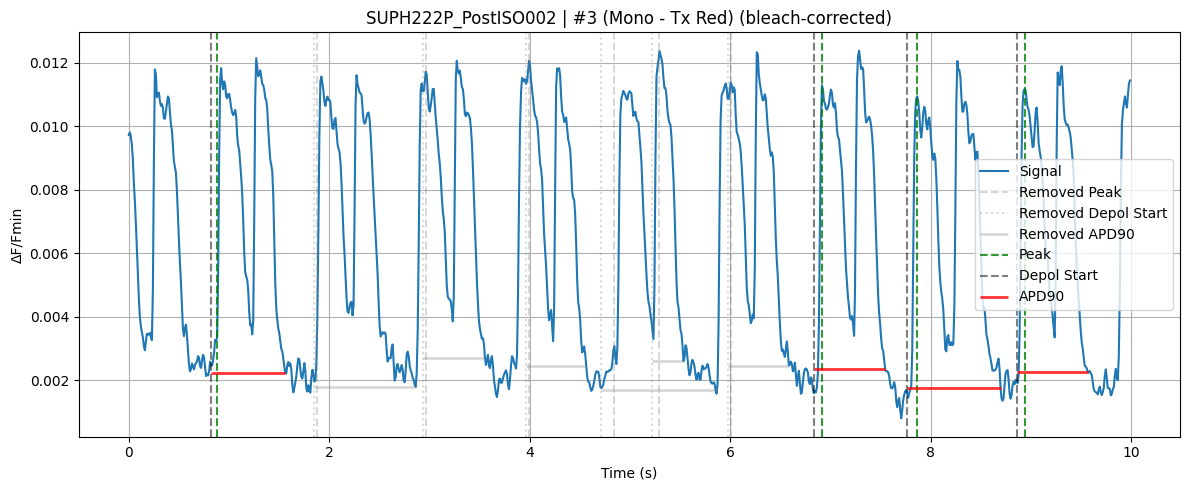

Displaying plot for: SUPH222P_PostISO002 | #4 (Mono - Tx Red)


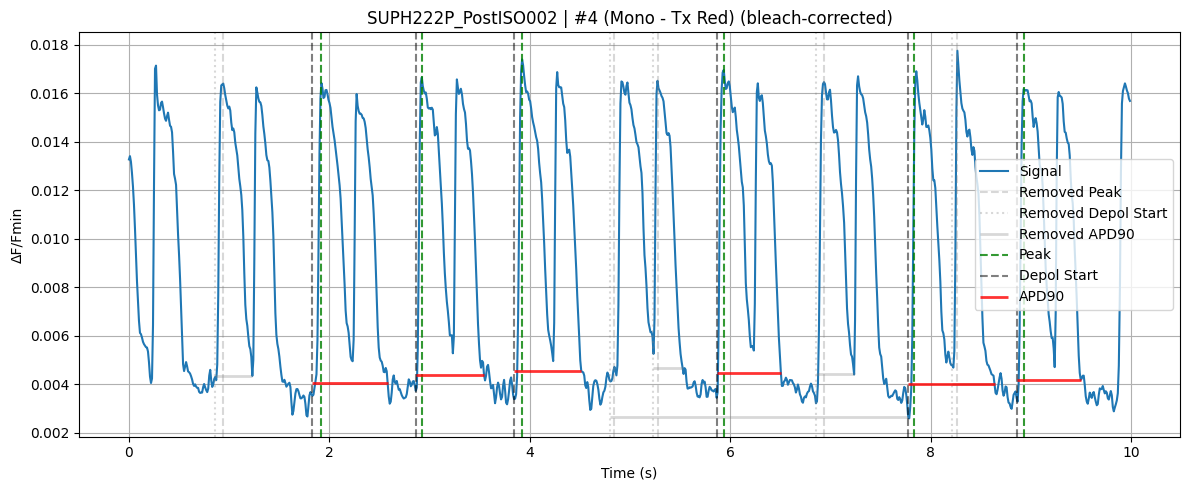

Displaying plot for: SUPH222P_PostISO002 | #5 (Mono - Tx Red)


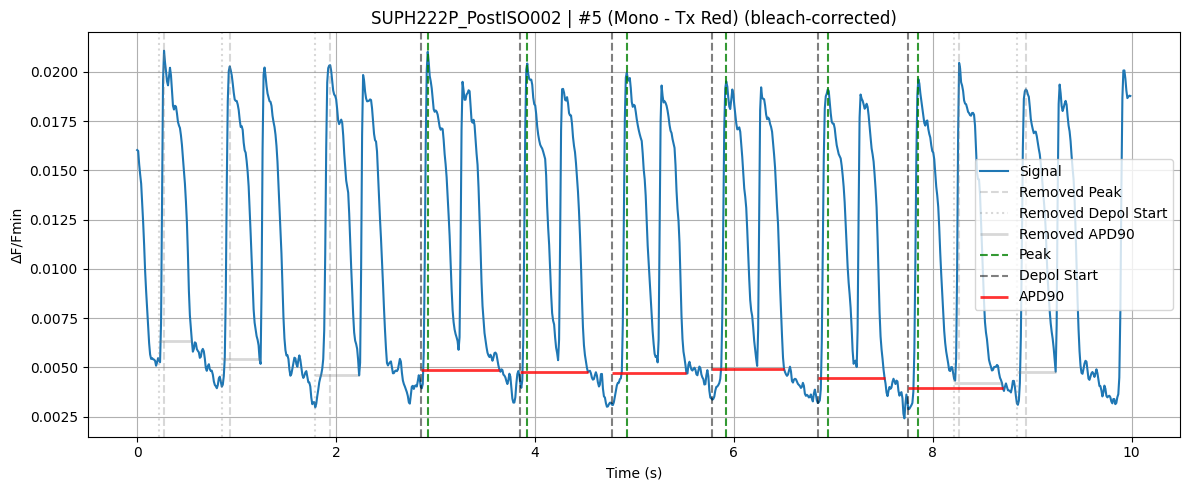

Displaying plot for: SUPH222P_PostISO002 | #6 (Mono - Tx Red)


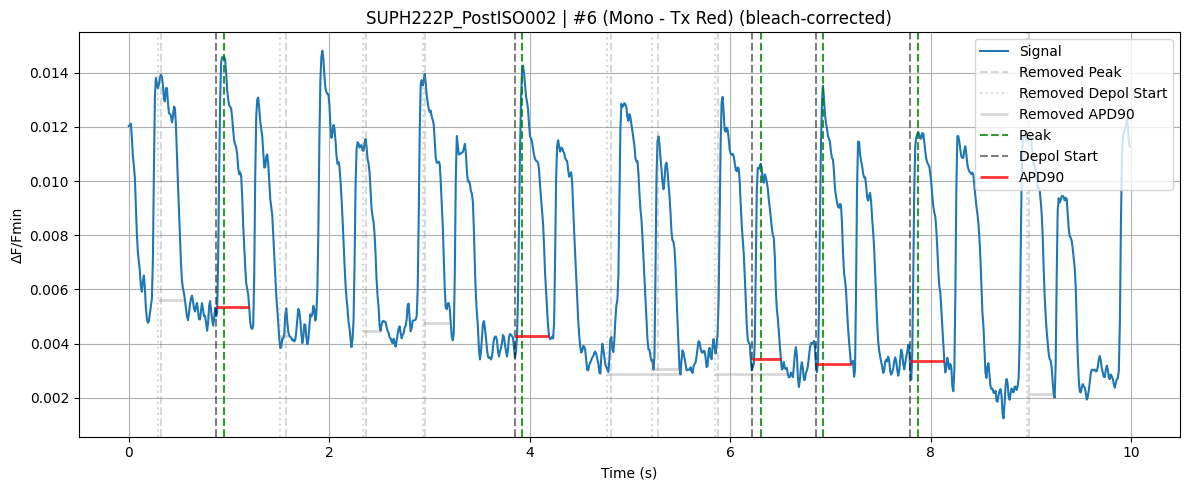

Displaying plot for: SUPH222P_PostISO002 | #7 (Mono - Tx Red)


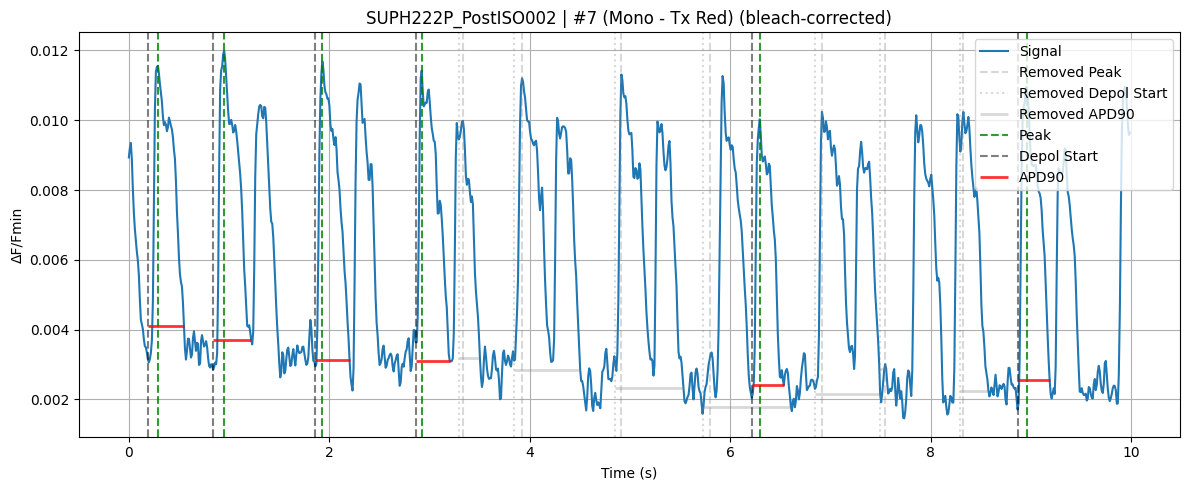

Displaying plot for: SUPH222P_PostISO002 | #8 (Mono - Tx Red)


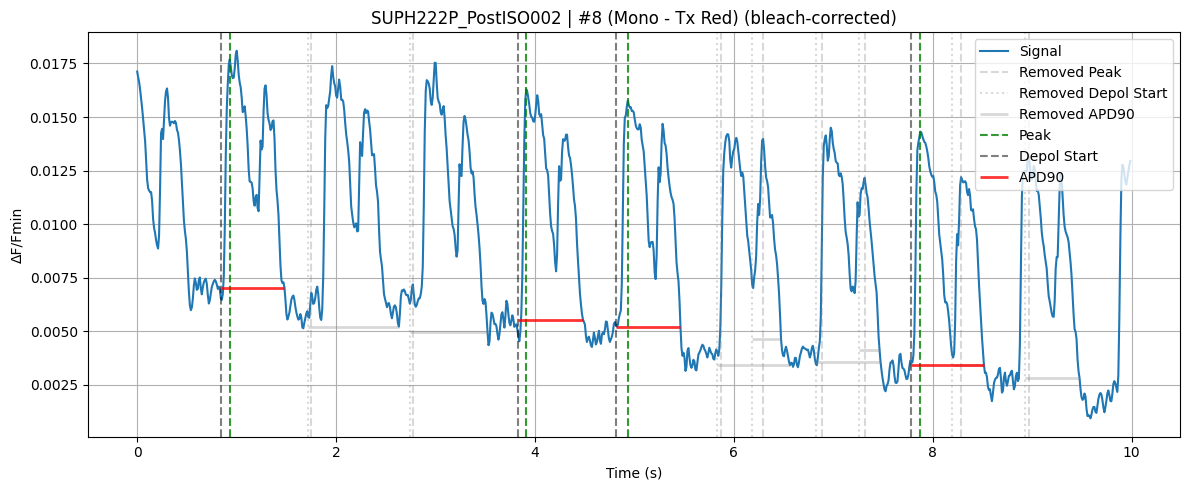

Displaying plot for: SUPH222P_PostISO002 | #9 (Mono - Tx Red)


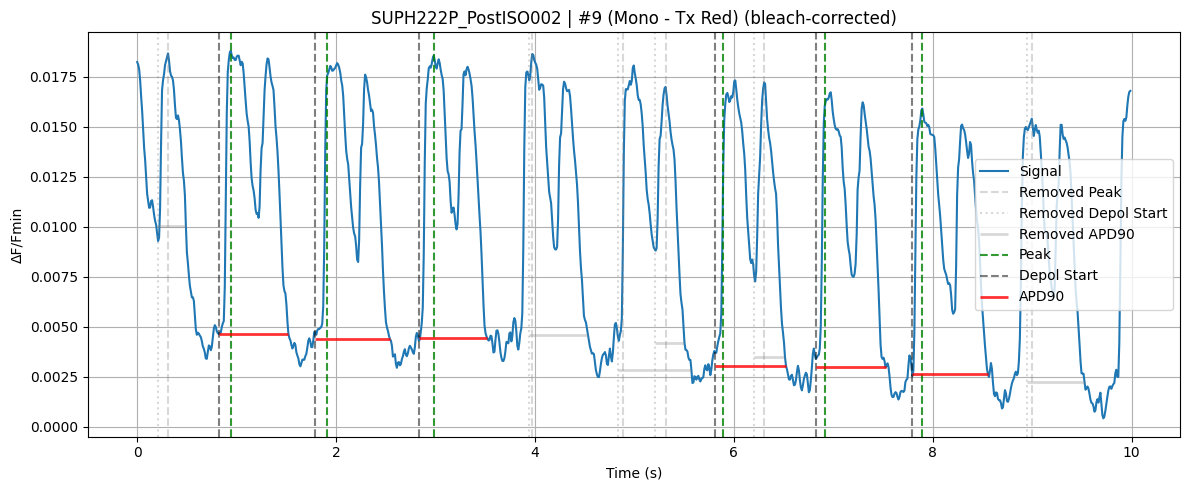

Displaying plot for: SUPH222P_PostISO002 | #10 (Mono - Tx Red)


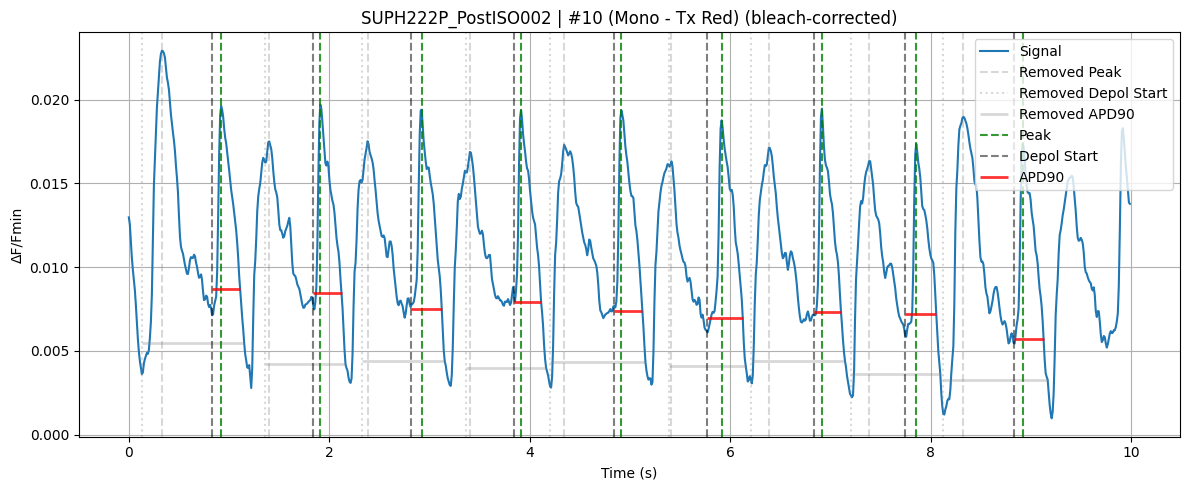

Displaying plot for: CRISPH222P_PreISO011 | #1 (Mono - Tx Red)


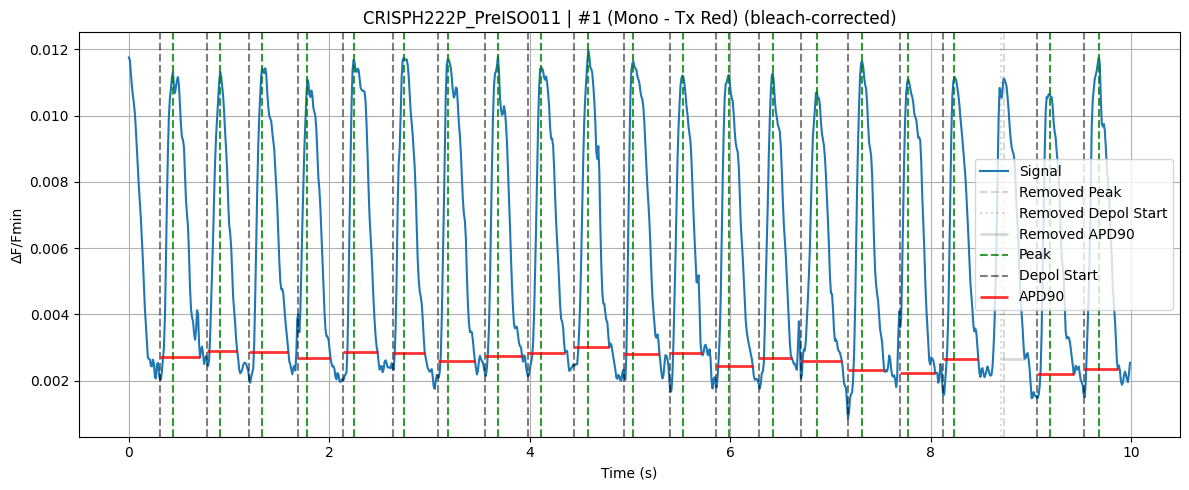

Displaying plot for: CRISPH222P_PreISO011 | #2 (Mono - Tx Red)


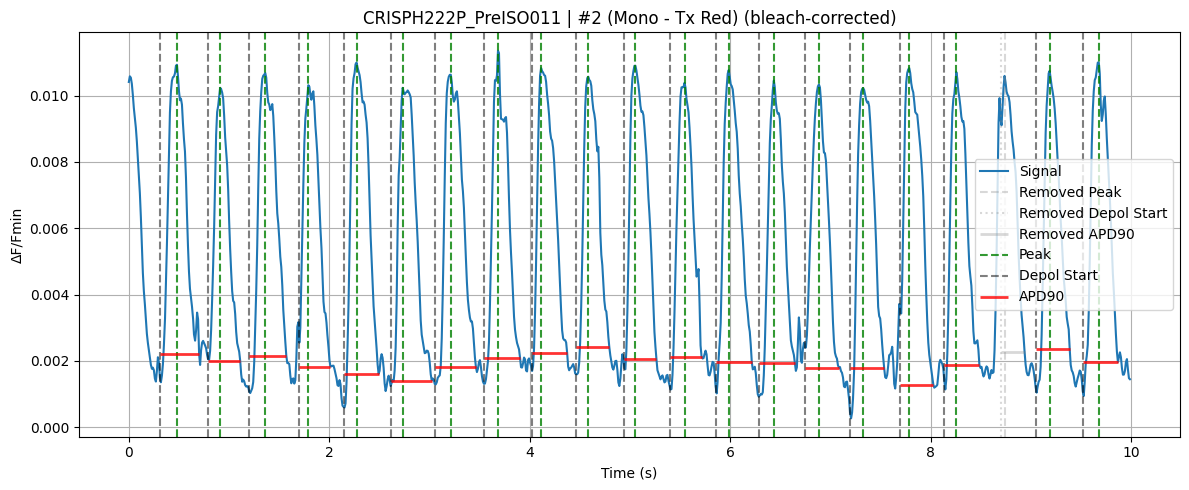

Displaying plot for: CRISPH222P_PreISO011 | #3 (Mono - Tx Red)


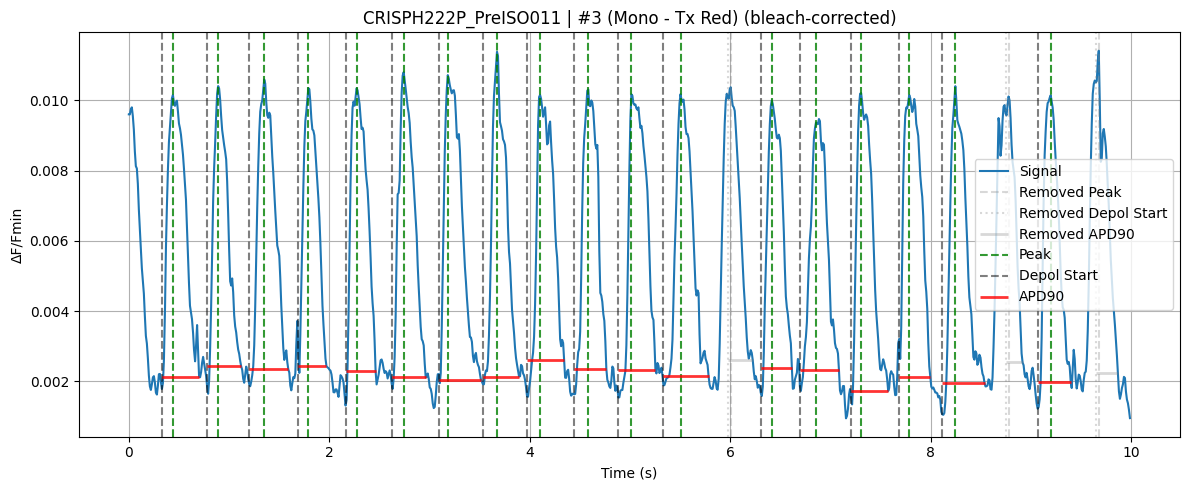

Displaying plot for: CRISPH222P_PreISO011 | #4 (Mono - Tx Red)


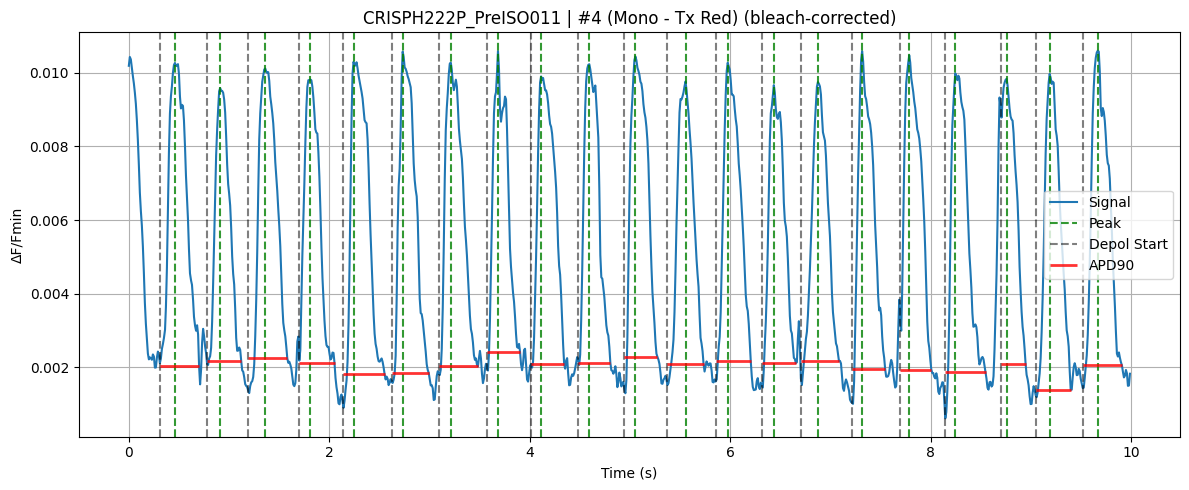

Displaying plot for: CRISPH222P_PreISO011 | #5 (Mono - Tx Red)


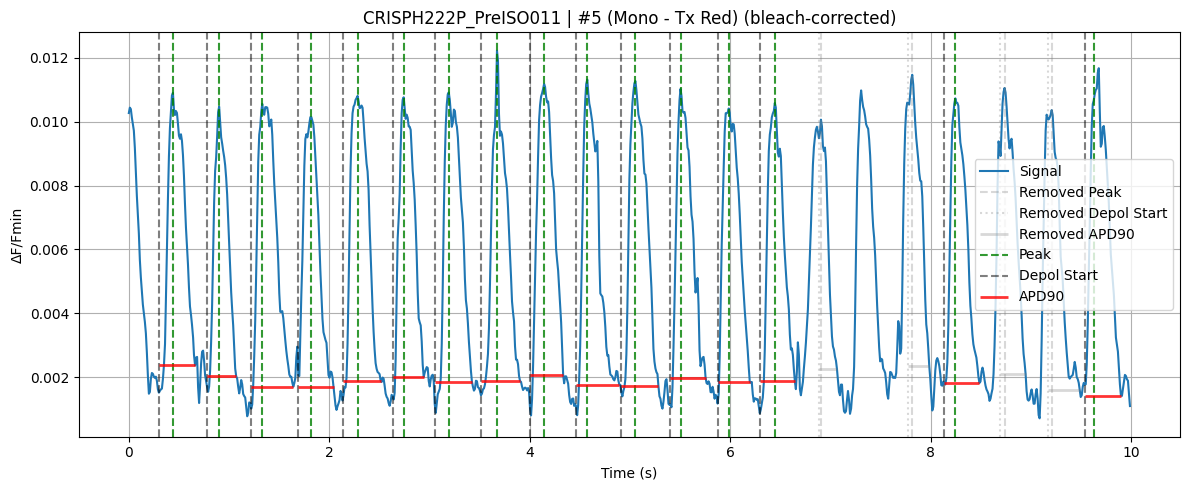

Displaying plot for: CRISPH222P_PreISO011 | #6 (Mono - Tx Red)


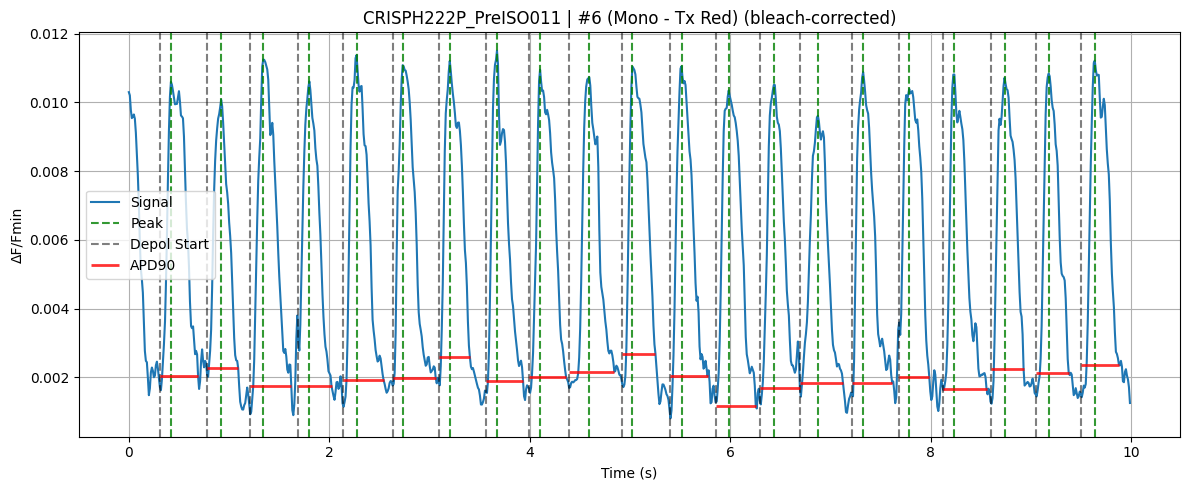

Displaying plot for: CRISPH222P_PreISO011 | #7 (Mono - Tx Red)


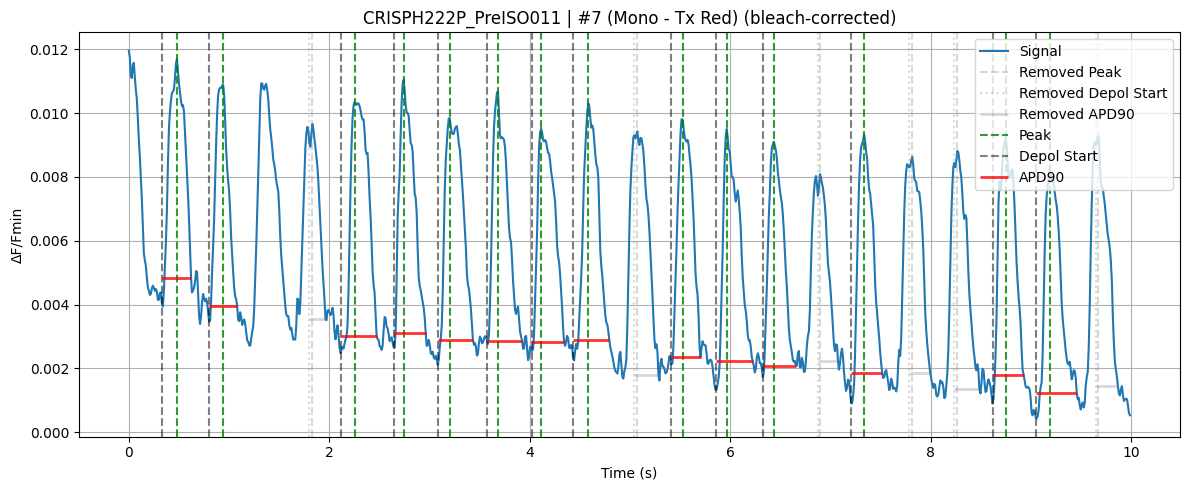

Displaying plot for: CRISPH222P_PreISO011 | #8 (Mono - Tx Red)


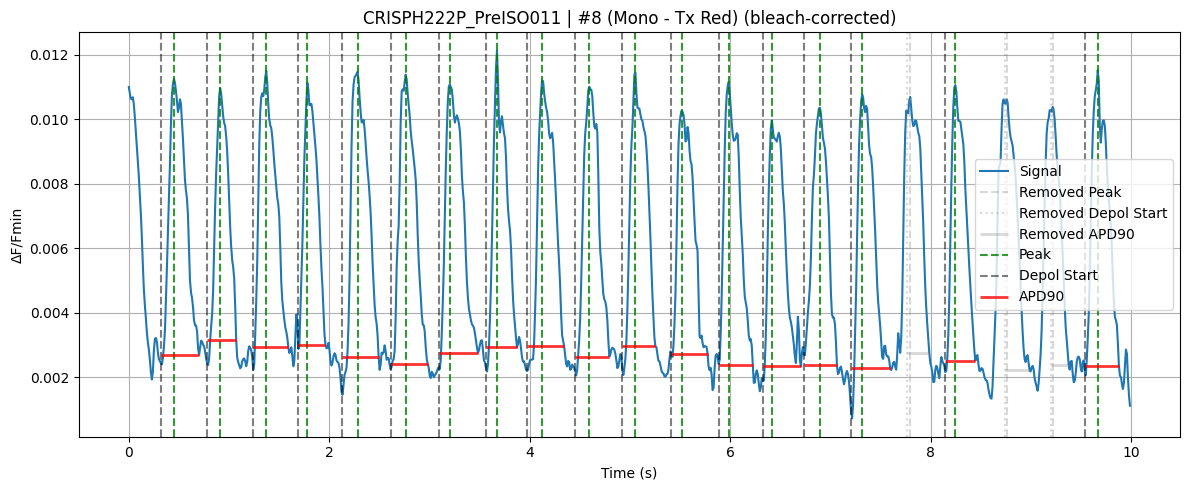

Displaying plot for: CRISPH222P_PreISO011 | #9 (Mono - Tx Red)


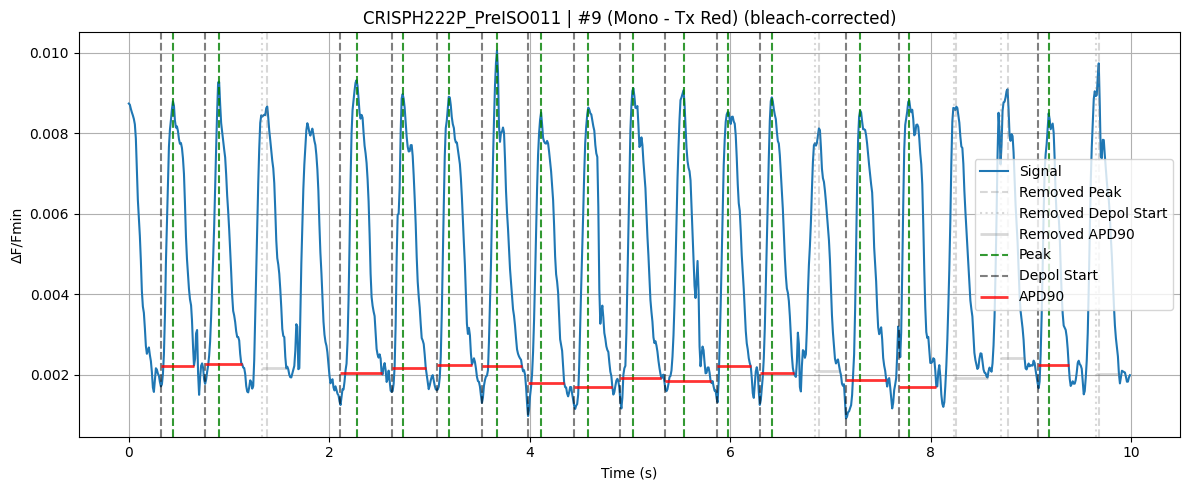

Displaying plot for: CRISPH222P_PreISO011 | #10 (Mono - Tx Red)


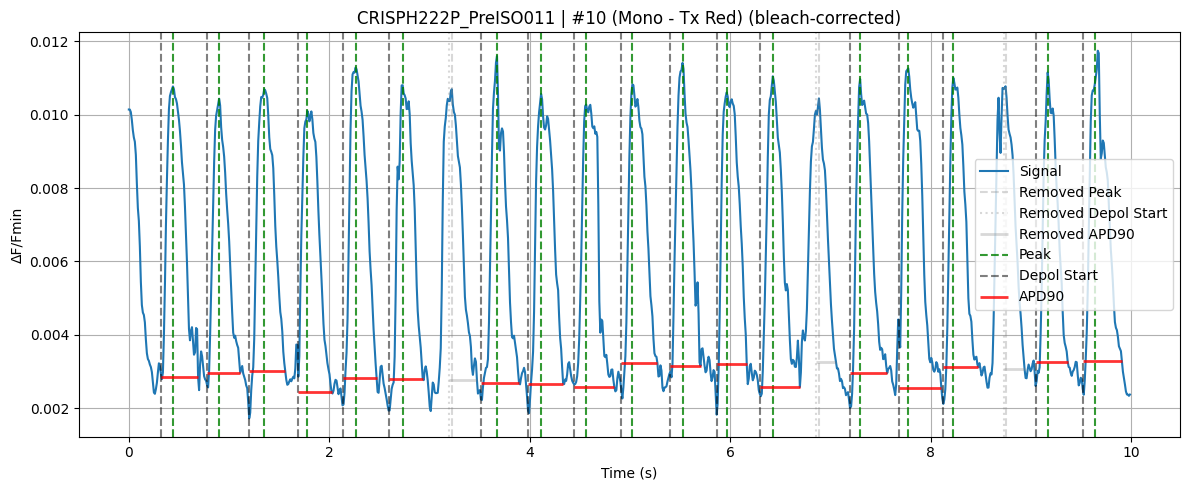

Displaying plot for: CRISPH222P_PreISO010 | #1 (Mono - Tx Red)


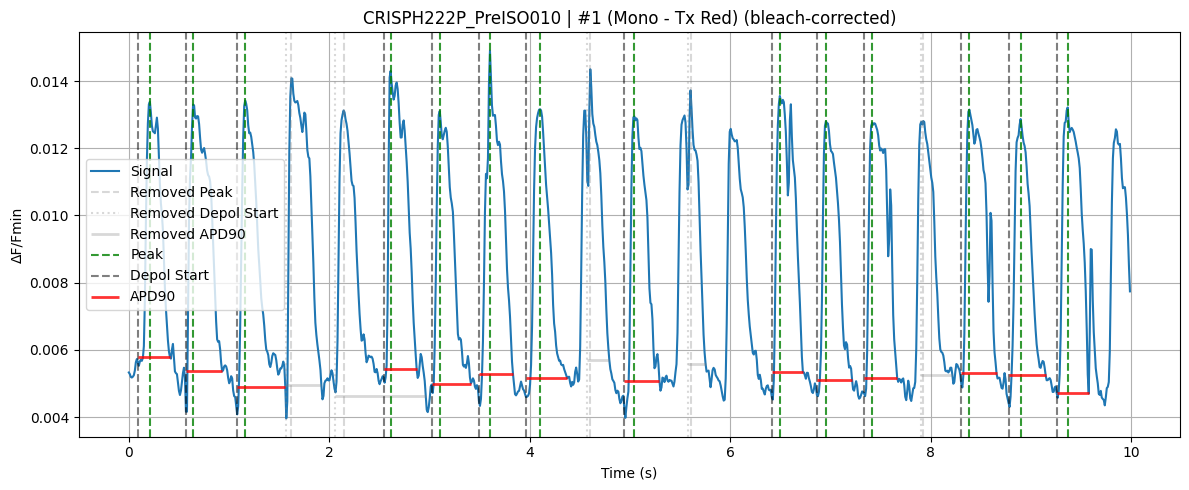

Displaying plot for: CRISPH222P_PreISO010 | #2 (Mono - Tx Red)


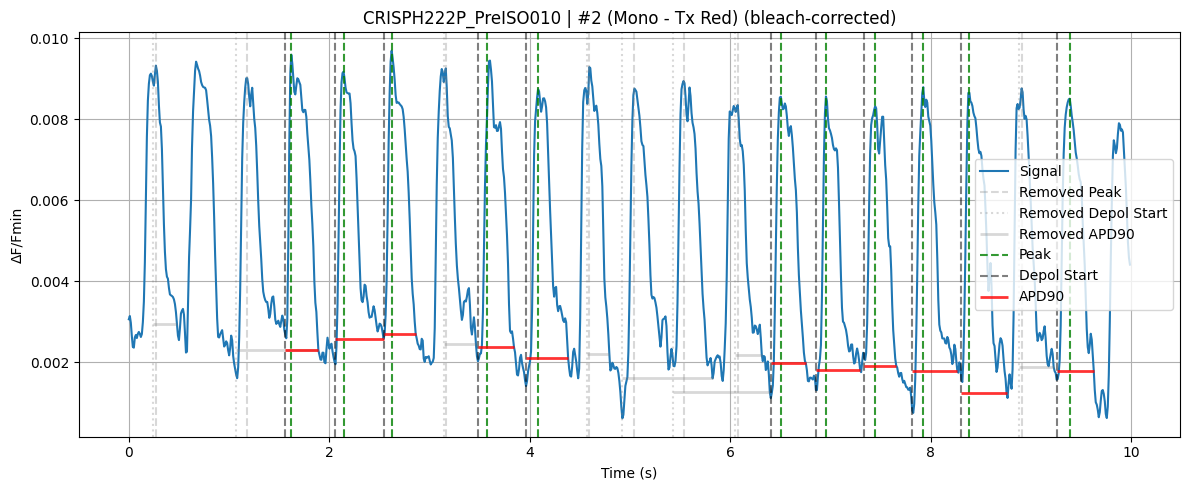

Displaying plot for: CRISPH222P_PreISO010 | #3 (Mono - Tx Red)


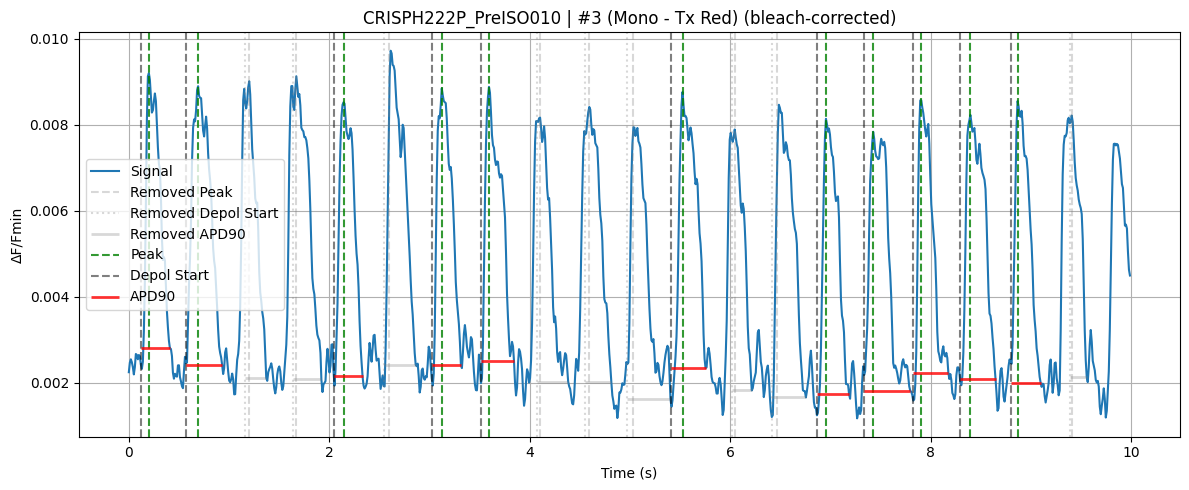

Displaying plot for: CRISPH222P_PreISO010 | #4 (Mono - Tx Red)


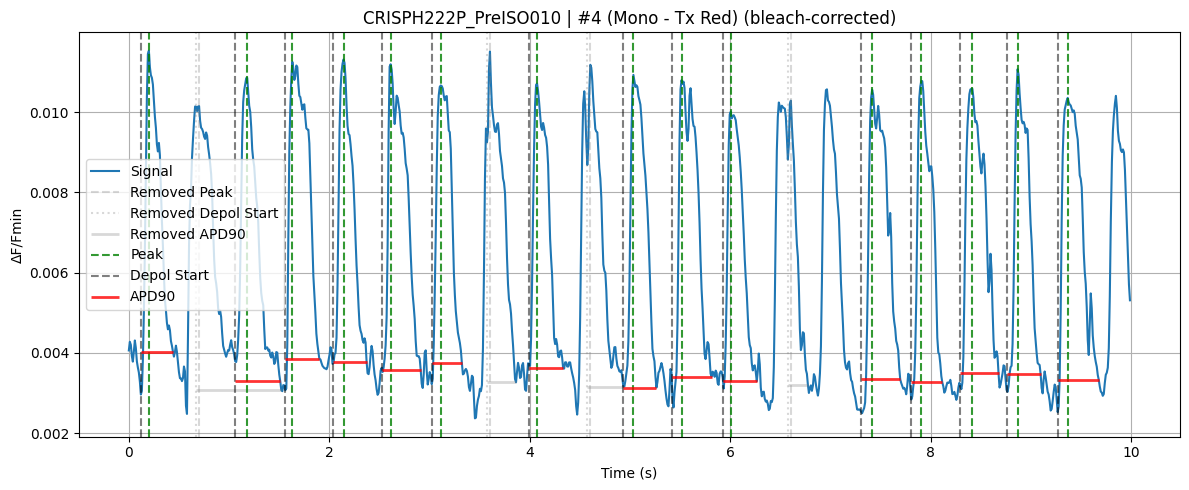

Displaying plot for: CRISPH222P_PreISO010 | #5 (Mono - Tx Red)


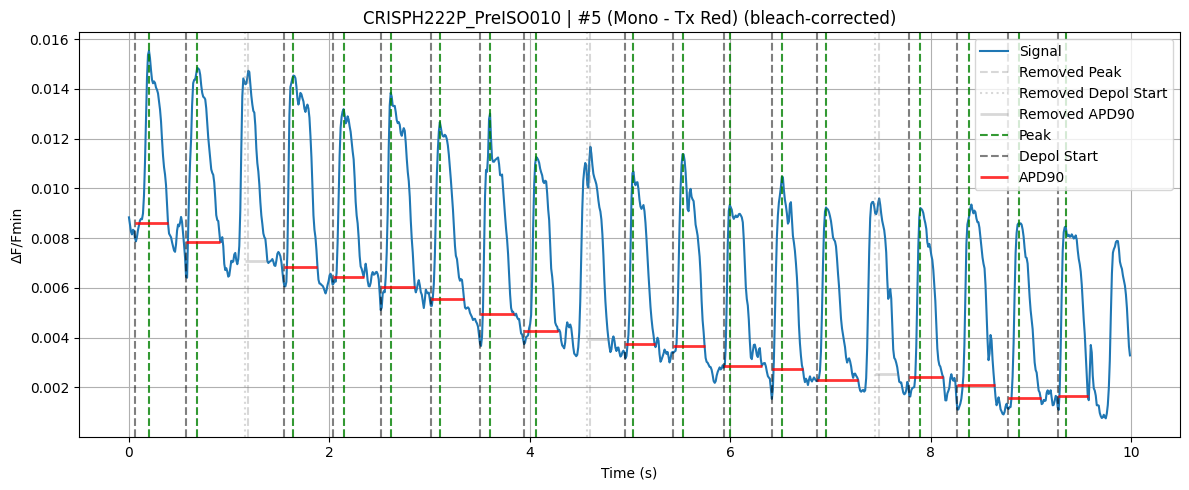

Displaying plot for: CRISPH222P_PreISO010 | #6 (Mono - Tx Red)


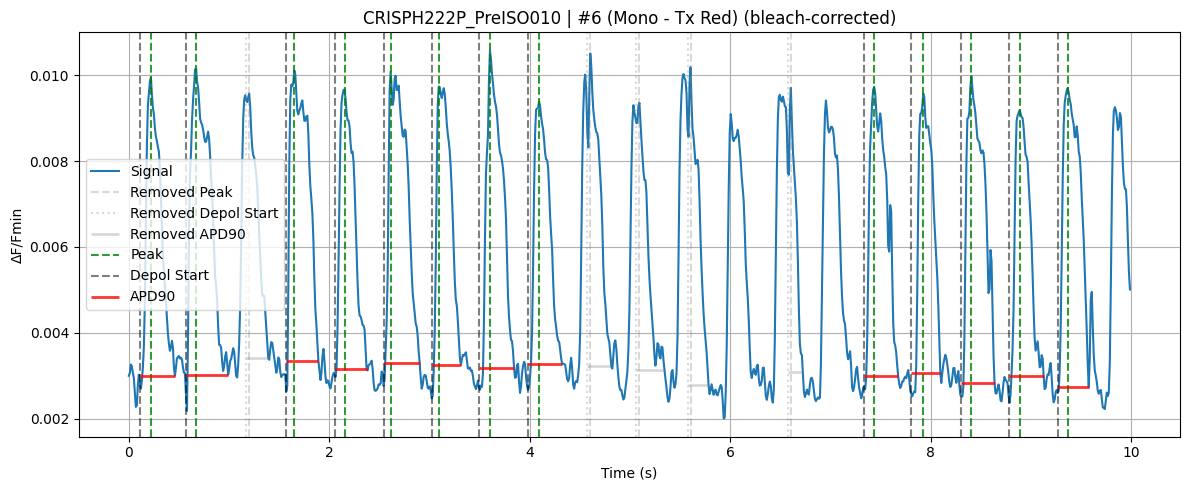

Displaying plot for: CRISPH222P_PreISO010 | #7 (Mono - Tx Red)


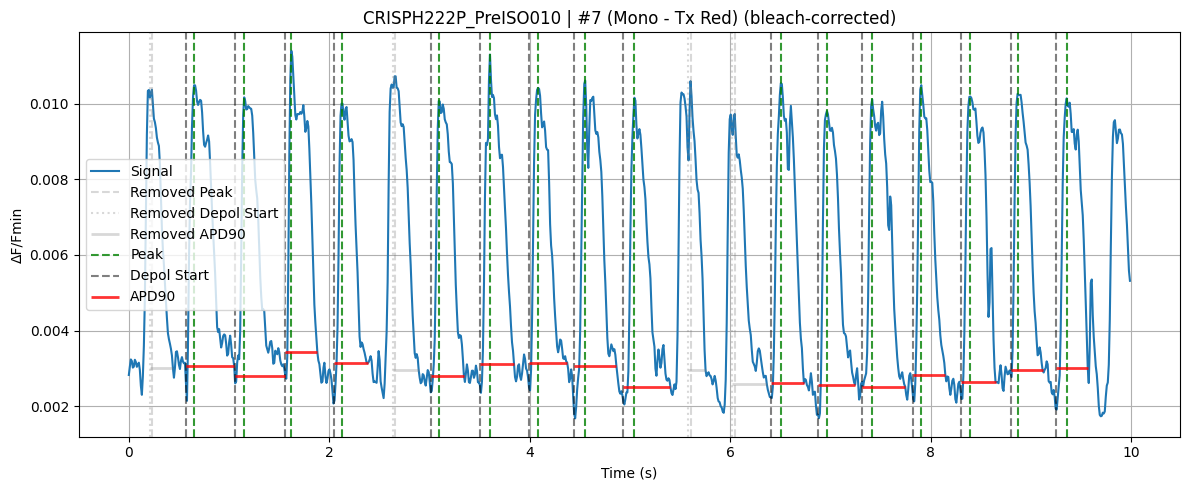

Displaying plot for: CRISPH222P_PreISO010 | #8 (Mono - Tx Red)


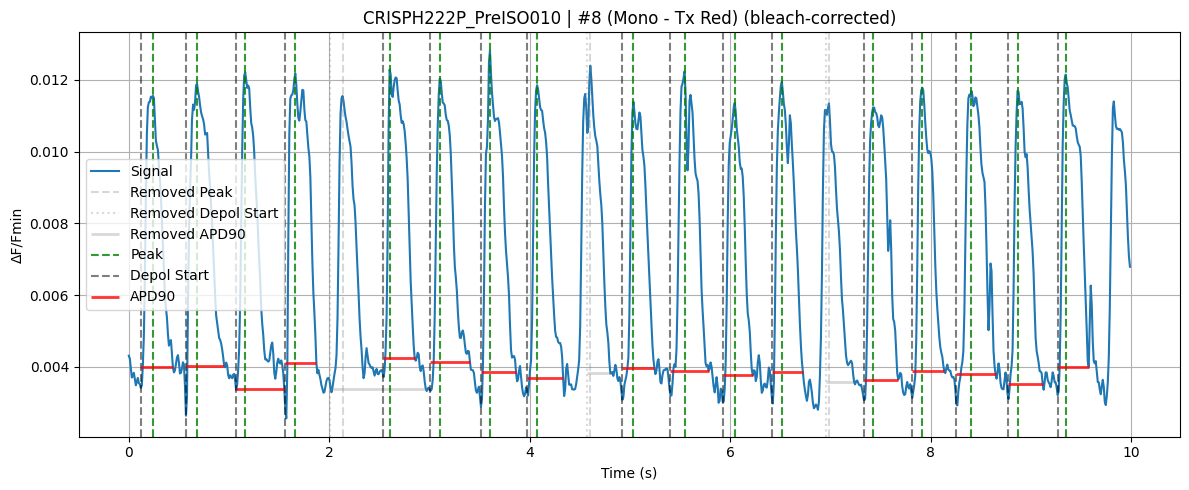

Displaying plot for: CRISPH222P_PreISO010 | #9 (Mono - Tx Red)


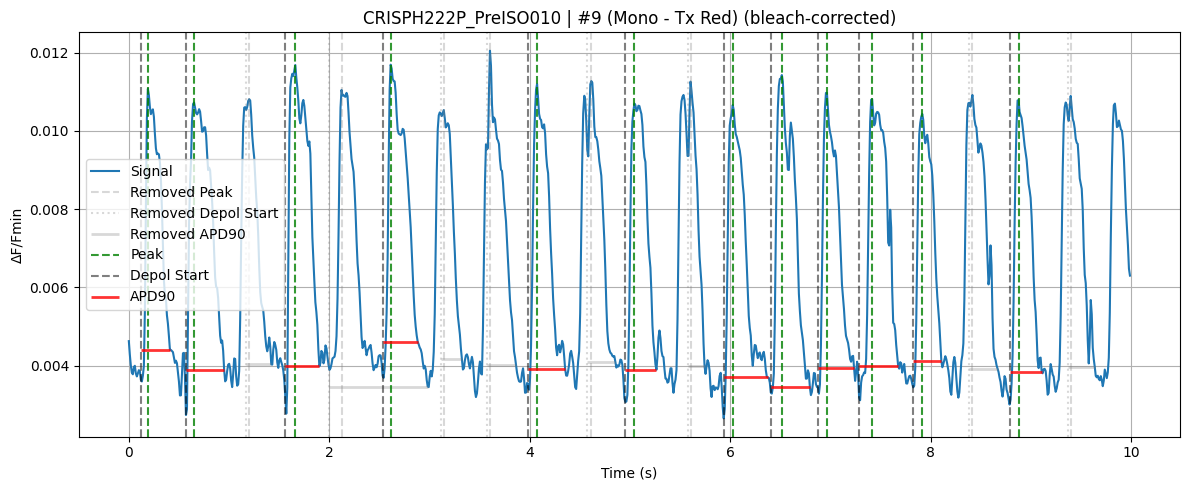

Displaying plot for: CRISPH222P_PreISO010 | #10 (Mono - Tx Red)


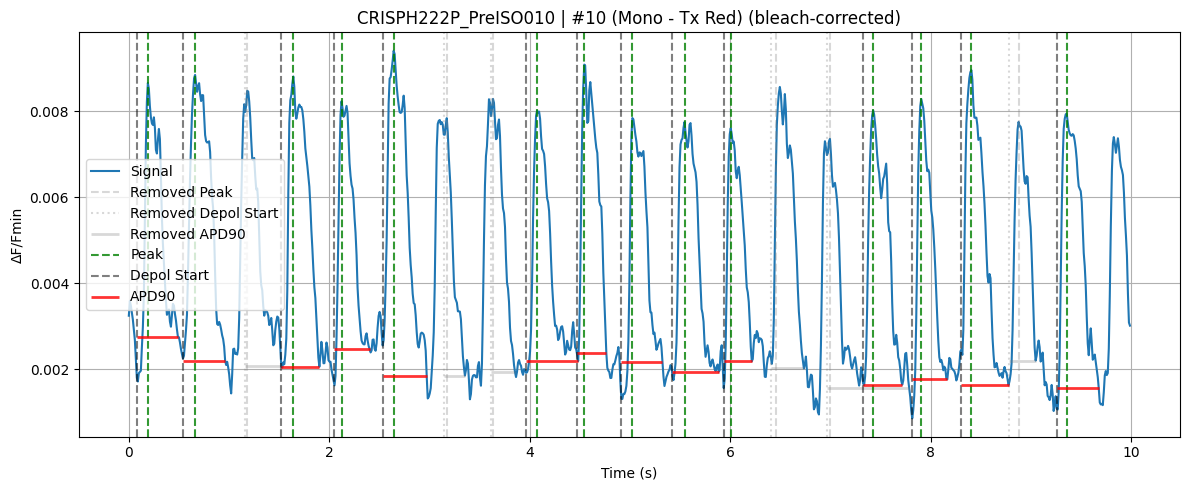

In [4]:
# ─── Cell 5: Main Loop — Call analyze_roi_signal on Each ROI ──────────────
all_results = []
plots       = []

for sheet_name in xls.sheet_names:
    raw = xls.parse(sheet_name, header=None, nrows=1)
    if raw.dropna(how='all').empty:
        continue
    sample_name = str(raw.iloc[0, 0])
    if sample_name.lower().endswith('.nd2'):
        sample_name = sample_name[:-4]

    df = xls.parse(sheet_name, header=1)
    if df.dropna(how='all').empty:
        continue
    df.columns = df.columns.astype(str).str.strip()

    time_cols = [c for c in df.columns if 'time' in c.lower()]
    if not time_cols:
        continue
    time = pd.to_numeric(df[time_cols[0]], errors='coerce').values

    roi_cols = [c for c in df.columns if c != time_cols[0] and '#' in c] #looks for non-time column AND containing #
    for roi in roi_cols:
        samp, roi_label, res_df, fig = analyze_roi_signal(
            time, df[roi], sample_name, roi,
            apply_filters=APPLY_FILTERS,
            grey_out_unfiltered=GREY_OUT_UNFILTERED
        )

        res_df.insert(0, 'Sample', samp)
        res_df.insert(1, 'ROI', roi_label)

        all_results.append(res_df)
        plots.append((samp, roi_label, fig))

        # === FIX: Display the plot immediately after creation ===
        print(f"Displaying plot for: {samp} | {roi_label}")
        display(fig)
        plt.close(fig) # Prevents the figure from being held in memory and displayed again later

In [5]:
# ─── Cell 6: Aggregate & Display Results ───────────────────────────────────
if all_results:
    summary_df = pd.concat(all_results, ignore_index=True)

    # === UPDATED: Sort the summary_df by Sample and numerical ROI ===
    summary_df['ROI_num'] = summary_df['ROI'].str.extract('(\d+)').astype(int)
    summary_df = summary_df.sort_values(by=['Sample', 'ROI_num']).drop(columns=['ROI_num']).reset_index(drop=True)

    print("Filtered summary:")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(summary_df)

    # === Calculate mean and standard deviation values per ROI ===
    mean_summary_df = summary_df.groupby(['Sample', 'ROI'])[[
        'Amplitude',
        'APD50_s',
        'APD90_s',
        'APD50_90_Ratio',
        'Upstroke_Time_s',
        'Repolarization_Time_s'
    ]].agg(['mean', 'std']).reset_index()
    
    # Flatten the column names after aggregation
    mean_summary_df.columns = ['_'.join(col).strip() for col in mean_summary_df.columns.values]
    mean_summary_df = mean_summary_df.rename(columns={'Sample_': 'Sample', 'ROI_': 'ROI'})


    # === UPDATED: Sort the mean_summary_df by Sample and numerical ROI ===
    mean_summary_df['ROI_num'] = mean_summary_df['ROI'].str.extract('(\d+)').astype(int)
    mean_summary_df = mean_summary_df.sort_values(by=['Sample', 'ROI_num']).drop(columns=['ROI_num']).reset_index(drop=True)

print("Filtered summary:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(summary_df)

print("\nMean values per ROI:")
display(mean_summary_df)

Filtered summary:


,Sample,ROI,_orig,Depolarization_Start_Time_s,Peak_Time_s,Amplitude,APD50_s,APD90_s,APD50_90_Ratio,Upstroke_Time_s,Repolarization_Time_s,Repolarization_Level
0,CRISPH222P_PreISO010,#1 (Mono - Tx Red),0,0.090,0.210,0.008299,0.260,0.320,0.812500,0.120,0.410,0.005784
1,CRISPH222P_PreISO010,#1 (Mono - Tx Red),1,0.570,0.641,0.008642,0.281,0.361,0.778393,0.071,0.931,0.005360
2,CRISPH222P_PreISO010,#1 (Mono - Tx Red),2,1.081,1.161,0.009259,0.220,0.480,0.458333,0.080,1.561,0.004902
3,CRISPH222P_PreISO010,#1 (Mono - Tx Red),5,2.542,2.612,0.009566,0.260,0.330,0.787879,0.070,2.872,0.005416
4,CRISPH222P_PreISO010,#1 (Mono - Tx Red),6,3.022,3.102,0.008960,0.240,0.391,0.613811,0.080,3.413,0.004997
5,CRISPH222P_PreISO010,#1 (Mono - Tx Red),7,3.493,3.603,0.010611,0.270,0.340,0.794118,0.110,3.833,0.005271
6,CRISPH222P_PreISO010,#1 (Mono - Tx Red),8,3.963,4.103,0.008832,0.260,0.410,0.634146,0.140,4.373,0.005157
7,CRISPH222P_PreISO010,#1 (Mono - Tx Red),10,4.944,5.044,0.008533,0.250,0.350,0.714286,0.100,5.294,0.005070
8,CRISPH222P_PreISO010,#1 (Mono - Tx Red),12,6.415,6.495,0.009068,0.260,0.310,0.838710,0.080,6.725,0.005336
9,CRISPH222P_PreISO010,#1 (Mono - Tx Red),13,6.865,6.955,0.008283,0.240,0.351,0.683761,0.090,7.216,0.005098


Filtered summary:


,Sample,ROI,_orig,Depolarization_Start_Time_s,Peak_Time_s,Amplitude,APD50_s,APD90_s,APD50_90_Ratio,Upstroke_Time_s,Repolarization_Time_s,Repolarization_Level
0,CRISPH222P_PreISO010,#1 (Mono - Tx Red),0,0.090,0.210,0.008299,0.260,0.320,0.812500,0.120,0.410,0.005784
1,CRISPH222P_PreISO010,#1 (Mono - Tx Red),1,0.570,0.641,0.008642,0.281,0.361,0.778393,0.071,0.931,0.005360
2,CRISPH222P_PreISO010,#1 (Mono - Tx Red),2,1.081,1.161,0.009259,0.220,0.480,0.458333,0.080,1.561,0.004902
3,CRISPH222P_PreISO010,#1 (Mono - Tx Red),5,2.542,2.612,0.009566,0.260,0.330,0.787879,0.070,2.872,0.005416
4,CRISPH222P_PreISO010,#1 (Mono - Tx Red),6,3.022,3.102,0.008960,0.240,0.391,0.613811,0.080,3.413,0.004997
5,CRISPH222P_PreISO010,#1 (Mono - Tx Red),7,3.493,3.603,0.010611,0.270,0.340,0.794118,0.110,3.833,0.005271
6,CRISPH222P_PreISO010,#1 (Mono - Tx Red),8,3.963,4.103,0.008832,0.260,0.410,0.634146,0.140,4.373,0.005157
7,CRISPH222P_PreISO010,#1 (Mono - Tx Red),10,4.944,5.044,0.008533,0.250,0.350,0.714286,0.100,5.294,0.005070
8,CRISPH222P_PreISO010,#1 (Mono - Tx Red),12,6.415,6.495,0.009068,0.260,0.310,0.838710,0.080,6.725,0.005336
9,CRISPH222P_PreISO010,#1 (Mono - Tx Red),13,6.865,6.955,0.008283,0.240,0.351,0.683761,0.090,7.216,0.005098



Mean values per ROI:


,Sample,ROI,Amplitude_mean,Amplitude_std,APD50_s_mean,APD50_s_std,APD90_s_mean,APD90_s_std,APD50_90_Ratio_mean,APD50_90_Ratio_std,Upstroke_Time_s_mean,Upstroke_Time_s_std,Repolarization_Time_s_mean,Repolarization_Time_s_std
0,CRISPH222P_PreISO010,#1 (Mono - Tx Red),0.008869,0.000641,0.257286,0.017843,0.358143,0.044786,0.730833,0.114071,0.095071,0.021663,5.119643,3.096569
1,CRISPH222P_PreISO010,#2 (Mono - Tx Red),0.007361,0.000526,0.263727,0.016877,0.391091,0.060917,0.692922,0.134644,0.097273,0.020045,5.807091,2.764590
2,CRISPH222P_PreISO010,#3 (Mono - Tx Red),0.006937,0.000193,0.247545,0.029149,0.334909,0.049233,0.745343,0.081211,0.092818,0.015079,5.225909,3.189107
3,CRISPH222P_PreISO010,#4 (Mono - Tx Red),0.008047,0.000324,0.252800,0.028865,0.358133,0.041550,0.709435,0.070629,0.096667,0.015430,5.159867,3.026089
4,CRISPH222P_PreISO010,#5 (Mono - Tx Red),0.007762,0.000483,0.258412,0.021852,0.336118,0.029610,0.773710,0.085406,0.100647,0.018564,5.092706,2.904436
5,CRISPH222P_PreISO010,#6 (Mono - Tx Red),0.007316,0.000395,0.251769,0.021568,0.336385,0.033879,0.752641,0.074906,0.098538,0.015741,4.862154,3.291510
6,CRISPH222P_PreISO010,#7 (Mono - Tx Red),0.008240,0.000361,0.257125,0.029042,0.375938,0.063624,0.696877,0.110701,0.090063,0.014562,5.369125,2.864529
7,CRISPH222P_PreISO010,#8 (Mono - Tx Red),0.008769,0.000441,0.255471,0.024128,0.349588,0.046193,0.740367,0.099602,0.104176,0.020038,5.082059,2.968658
8,CRISPH222P_PreISO010,#9 (Mono - Tx Red),0.007719,0.000459,0.253417,0.033195,0.351833,0.046556,0.726676,0.092175,0.092583,0.015377,5.088000,2.950125
9,CRISPH222P_PreISO010,#10 (Mono - Tx Red),0.006883,0.000640,0.263786,0.027959,0.400214,0.065962,0.672572,0.107058,0.100857,0.017258,4.980857,2.952712


In [6]:
# ─── Cell 7: Output ───────────────────────────────────
# === Dynamically build out_path using os.path ===
folder, basename = os.path.split(SYNTHETIC_EXCEL)
name, ext       = os.path.splitext(basename)
new_name        = f"{name}_BatchAnalysis{ext}"
out_path        = os.path.join(folder, new_name)

# === ADDED: Sort the plots list to match the summary sheet order ===
# This will sort the plots first by sample name, then by the numerical ROI number
plots.sort(key=lambda x: (x[0], int(re.search(r'#(\d+)', x[1]).group(1))))


# === Write summary_df, mean_summary_df, and plots into the new workbook ===
with pd.ExcelWriter(out_path, engine='xlsxwriter') as writer:
    # 1) summary table
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

    # 2) mean values table
    mean_summary_df.to_excel(writer, sheet_name='Mean_Values', index=False)

    # 3) embed plots
    workbook  = writer.book
    worksheet = workbook.add_worksheet('Plots')

    img_row = 0
    for sample, roi, fig in plots:
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)

        worksheet.write(img_row, 0, f"{sample} | {roi}")
        img_row += 1

        worksheet.insert_image(
            img_row, 0,
            f"{sample}_{roi}.png",
            {'image_data': buf, 'x_scale': 0.8, 'y_scale': 0.8}
        )
        img_row += 30

print(f"\n✅ Saved batch analysis to:\n  {out_path}")


✅ Saved batch analysis to:
  Sup_Rep_BeRST_pilot_excel_SYNTHETIC_BatchAnalysis.xlsx
